# 🚀 Mini Portfolio Assignment — E-Commerce Sales Analysis
## Data Analytics Bootcamp

---
**Nama    :** _Nayaka Khansa Alana_  
**Tanggal :** _15/5/26_  
**Dataset :** [Online Retail Dataset](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

### Tujuan Analisis
Sebagai Junior Data Analyst, kita diminta menganalisis data penjualan e-commerce untuk:
1. Memahami performa penjualan per kategori & region
2. Mengidentifikasi dampak diskon terhadap profitabilitas
3. Menemukan pola musiman (seasonal trend)
4. Memberikan rekomendasi bisnis yang actionable

---


##Cell 1 — Import Libraries

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# =========================
# PENGATURAN VISUAL
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ Libraries berhasil di-import!")
print(f"   Pandas v{pd.__version__} | NumPy v{np.__version__}")

✅ Libraries berhasil di-import!
   Pandas v2.2.2 | NumPy v2.0.2


##Cell 2 — Load Data
> 💡 Jika file `online retail.xlsx` belum ada, jalankan fungsi `generate_superstore_data()` di bawah ini untuk membuat sample data.

In [ ]:
# =========================
# LOAD DATASET ONLINE RETAIL
# =========================

try:
    # Membaca file Excel
    df_raw = pd.read_excel("Online Retail.xlsx")

    print("✅ File 'Online Retail.xlsx' berhasil dimuat!")

    # Menampilkan ukuran dataset
    print(f"Jumlah baris  : {df_raw.shape[0]}")
    print(f"Jumlah kolom  : {df_raw.shape[1]}")

except FileNotFoundError:
    print("❌ File 'Online Retail.xlsx' tidak ditemukan!")

✅ File 'Online Retail.xlsx' berhasil dimuat!
Jumlah baris  : 541909
Jumlah kolom  : 8


##Cell 3 — Step 1: Data Exploration

In [ ]:
print(f"\n📐 Shape Dataset:")
print(f"{df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")


📐 Shape Dataset:
541,909 baris × 8 kolom


In [ ]:
print("\n📌 Nama Kolom:")
print(df_raw.columns.tolist())


📌 Nama Kolom:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [ ]:
print("\n📌 5 Data Teratas:")
print(df_raw.head())


📌 5 Data Teratas:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
print("=== INFO DATASET ===")
df_raw.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)

=== STATISTIK DESKRIPTIF ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [ ]:
# =========================
# MISSING VALUES
# =========================

print("=== MISSING VALUES ===")

missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    "Count": missing,
    "Pct %": pct
})

# Tampilkan hanya kolom yang memiliki missing values
print(missing_df[missing_df["Count"] > 0])

=== MISSING VALUES ===
              Count  Pct %
Description    1454   0.27
CustomerID   135080  24.93


In [ ]:
# =========================
# DISTRIBUSI KOLOM KATEGORIK
# =========================

# Kolom kategorik yang sesuai dataset Online Retail
categorical_cols = [
    "Country",
    "Description",
    "StockCode"
]

for col in categorical_cols:
    if col in df_raw.columns:

        print(f"\n=== Distribusi {col} ===")

        # Menampilkan 10 data terbanyak
        print(df_raw[col].value_counts().head(10))


=== Distribusi Country ===
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

=== Distribusi Description ===
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

=== Distribusi StockCode ===
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     135

##Cell 4 — Step 2: Data Cleaning

In [ ]:
# =========================
# DATA CLEANING - ONLINE RETAIL
# =========================

# Copy dataset asli
df = df_raw.copy()

# =========================
# 1. HANDLE MISSING VALUES
# =========================

# Hapus baris dengan CustomerID kosong
df = df.dropna(subset=['CustomerID'])

# Isi Description kosong
df['Description'] = df['Description'].fillna("Unknown Product")

# =========================
# 2. REMOVE INVALID DATA
# =========================

# Hapus quantity <= 0 (retur / data tidak valid)
df = df[df['Quantity'] > 0]

# Hapus harga <= 0
df = df[df['UnitPrice'] > 0]

# =========================
# 3. REMOVE DUPLICATES
# =========================

df = df.drop_duplicates()

# =========================
# 4. FIX DATA TYPES
# =========================

# Konversi tanggal
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# CustomerID menjadi integer
df['CustomerID'] = df['CustomerID'].astype(int)

# =========================
# 5. FEATURE ENGINEERING
# =========================

# Total transaksi
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Tahun
df['Year'] = df['InvoiceDate'].dt.year

# Bulan angka
df['Month'] = df['InvoiceDate'].dt.month

# Nama bulan
df['Month_Name'] = df['InvoiceDate'].dt.strftime('%b')

# Quarter
df['Quarter'] = df['InvoiceDate'].dt.quarter.map({
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
})

# Hari transaksi
df['Day'] = df['InvoiceDate'].dt.day

# Hari dalam minggu
df['Day_Name'] = df['InvoiceDate'].dt.day_name()

# Jam transaksi
df['Hour'] = df['InvoiceDate'].dt.hour


In [ ]:
# =========================
# HASIL CLEANING
# =========================

print(f"✅ Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom")

print("\n📌 Kolom Dataset:")
print(df.columns.tolist())

print("\n📌 5 Data Teratas:")
print(df.head())

✅ Data bersih: 392,692 baris × 16 kolom

📌 Kolom Dataset:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Day_Name', 'Hour']

📌 5 Data Teratas:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75       17850  United Kingdom       22.00

In [ ]:
# =========================
# EXPORT HASIL CLEANING KE EXCEL
# =========================

# Nama file output
output_file = "Online_Retail_Cleaned.xlsx"

# Export ke Excel
df.to_excel(output_file, index=False)

print(f"✅ Dataset hasil cleaning berhasil disimpan ke:")
print(f"📁 {output_file}")


✅ Dataset hasil cleaning berhasil disimpan ke:
📁 Online_Retail_Cleaned.xlsx


In [ ]:
# =========================
# OPTIONAL: EXPORT CSV
# =========================

csv_file = "Online_Retail_Cleaned.csv"

df.to_csv(csv_file, index=False)

print(f"\n✅ Dataset juga disimpan ke CSV:")
print(f"📁 {csv_file}")


✅ Dataset juga disimpan ke CSV:
📁 Online_Retail_Cleaned.csv


## Cell 5 — Step 3: Sales Analysis
### KPI Summary

In [ ]:
# =========================
# KPI SUMMARY - ONLINE RETAIL
# =========================

# Total revenue
total_sales = df['TotalPrice'].sum()

# Total transaksi/invoice
total_orders = df['InvoiceNo'].nunique()

# Total customer unik
total_customers = df['CustomerID'].nunique()

# Total produk terjual
total_quantity = df['Quantity'].sum()

# Average Order Value
avg_order_val = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()

# Rata-rata pembelian customer
avg_customer_spending = df.groupby('CustomerID')['TotalPrice'].sum().mean()

# Negara unik
total_countries = df['Country'].nunique()

# =========================
# MEMBUAT KPI DATAFRAME
# =========================

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products Sold",
        "Average Order Value",
        "Average Customer Spending",
        "Countries Served"
    ],

    "Value": [
        f"${total_sales:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_quantity:,}",
        f"${avg_order_val:,.2f}",
        f"${avg_customer_spending:,.2f}",
        f"{total_countries}"
    ]
})

# =========================
# TAMPILKAN KPI
# =========================

print("=== KPI SUMMARY ===")

kpi

=== KPI SUMMARY ===


,KPI,Value
0,Total Revenue,"$8,887,208.89"
1,Total Orders,"18,532"
2,Total Customers,"4,338"
3,Total Products Sold,"5,152,002"
4,Average Order Value,$479.56
5,Average Customer Spending,"$2,048.69"
6,Countries Served,37


###Sales by Category

In [ ]:
# =========================
# SALES ANALYSIS BY COUNTRY
# =========================

sales_by_country = df.groupby("Country").agg(
    Total_Sales=("TotalPrice", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Customers=("CustomerID", "nunique")
).sort_values("Total_Sales", ascending=False)

# Average Order Value per country
sales_by_country["Avg_Order_Value"] = (
    sales_by_country["Total_Sales"] / sales_by_country["Total_Orders"]
).round(2)

# =========================
# FORMAT OUTPUT
# =========================

sales_by_country.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Quantity": "{:,.0f}",
    "Total_Orders": "{:,.0f}",
    "Total_Customers": "{:,.0f}",
    "Avg_Order_Value": "${:,.2f}"
})

,Total_Sales,Total_Quantity,Total_Orders,Total_Customers,Avg_Order_Value
Country,,,,,
United Kingdom,"$7,285,024.64","4,241,305","16,646","3,920",$437.64
Netherlands,"$285,446.34","200,361",94,9,"$3,036.66"
EIRE,"$265,262.46","140,133",260,3,"$1,020.24"
Germany,"$228,678.40","119,154",457,94,$500.39
France,"$208,934.31","111,428",389,87,$537.11
Australia,"$138,453.81","83,891",57,9,"$2,429.01"
Spain,"$61,558.56","27,933",90,30,$683.98
Switzerland,"$56,443.95","30,082",51,21,"$1,106.74"
Belgium,"$41,196.34","23,237",98,25,$420.37


## Cell 6 — Step 4: Visualisasi
### Dashboard (4 Charts)

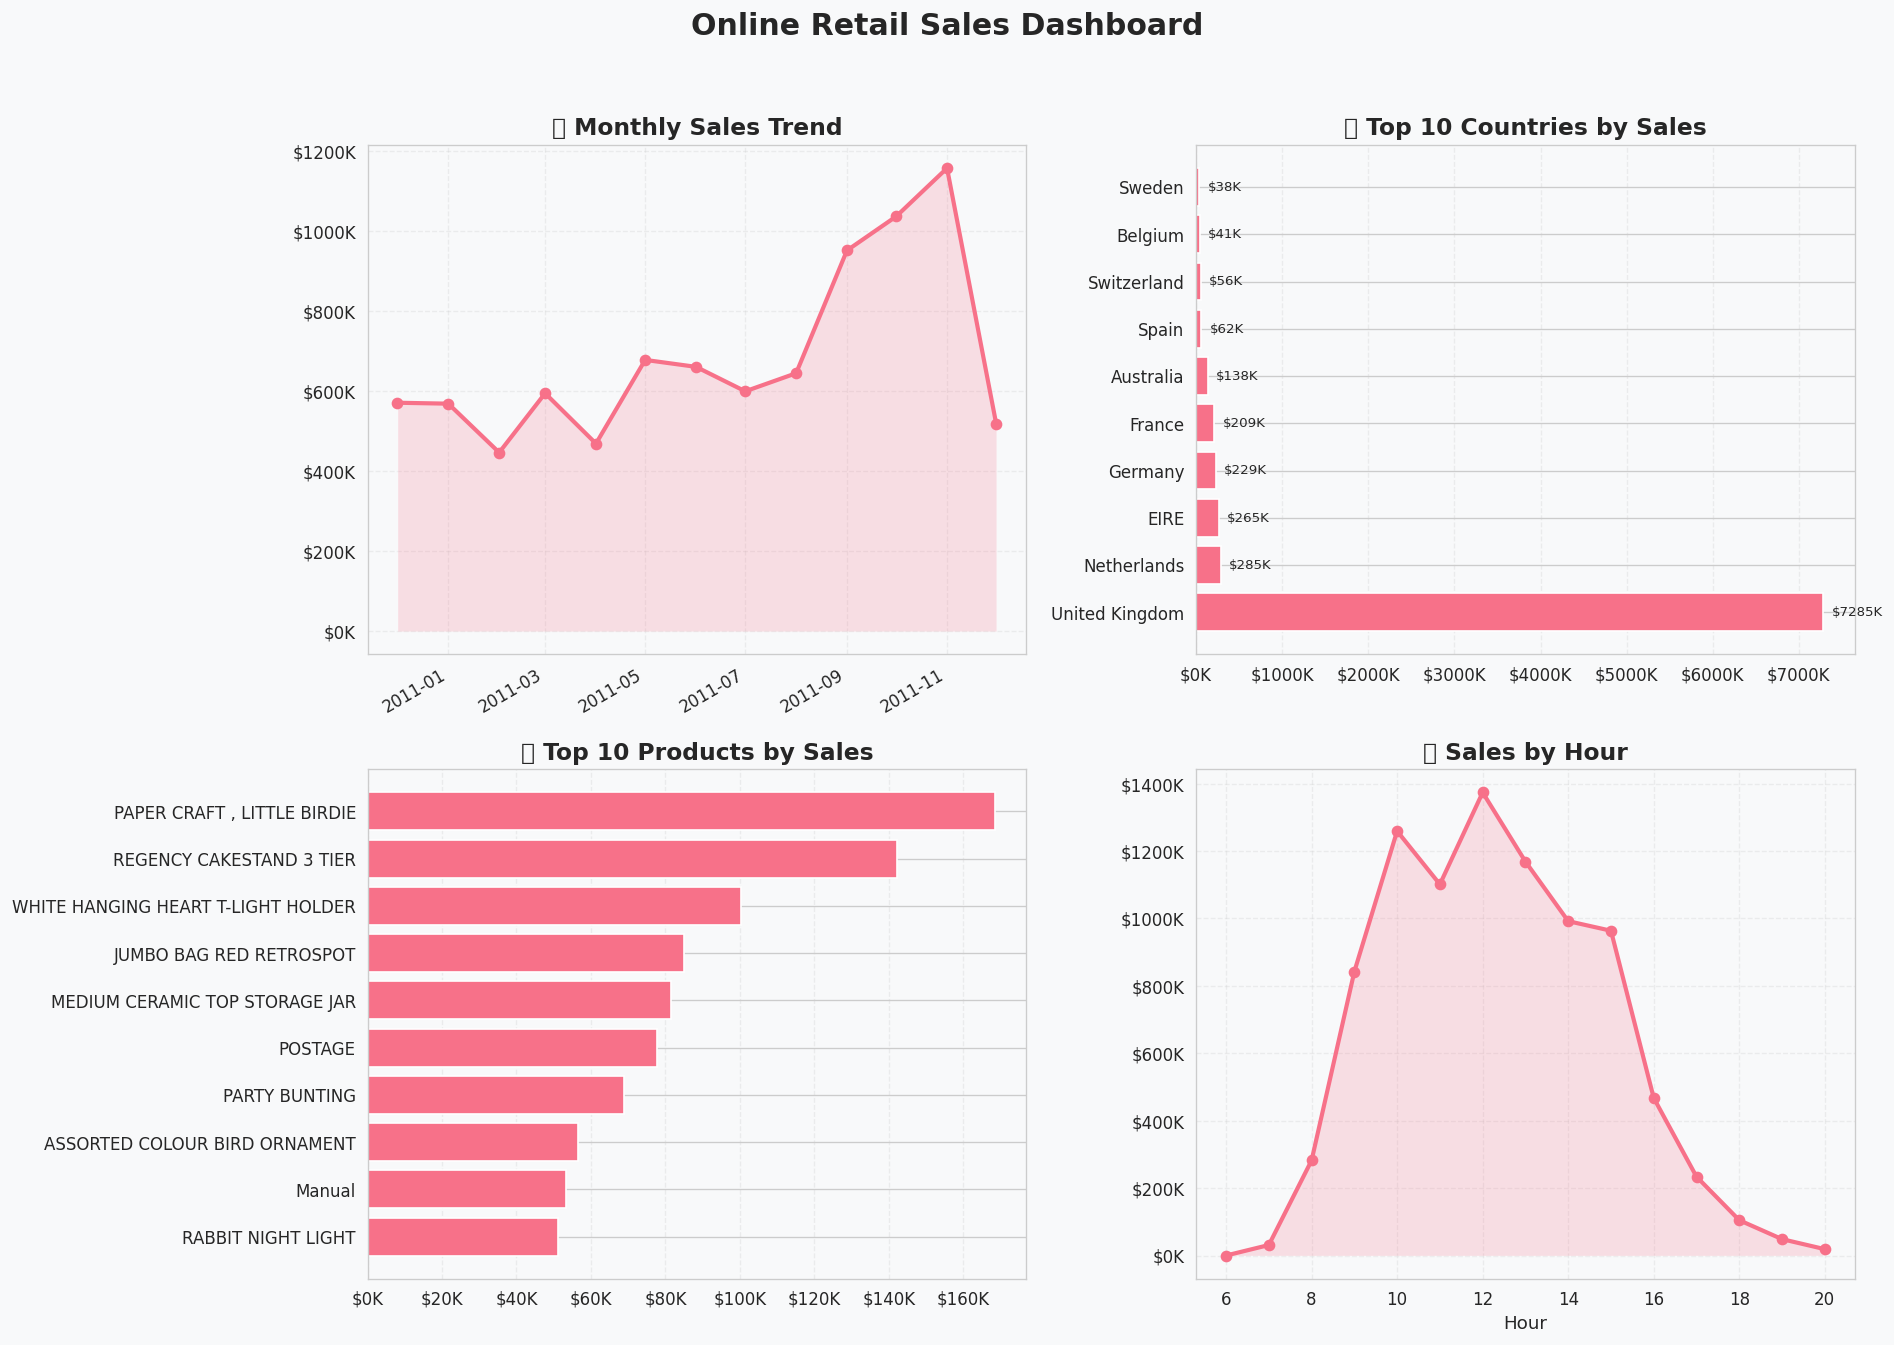

✅ Dashboard disimpan ke 'online_retail_dashboard.png'


In [ ]:
# =========================
# ONLINE RETAIL DASHBOARD
# =========================

FIG_COLOR = "#F8F9FA"

# =========================
# MONTHLY SALES
# =========================

monthly = df.groupby(["Year", "Month"]).agg(
    Total_Sales=("TotalPrice", "sum"),
    Total_Orders=("InvoiceNo", "nunique")
).reset_index()

monthly["Date"] = pd.to_datetime(
    monthly[["Year", "Month"]].assign(Day=1)
)

monthly = monthly.sort_values("Date")

# =========================
# COUNTRY SALES
# =========================

country_sales = df.groupby("Country").agg(
    Total_Sales=("TotalPrice", "sum")
).sort_values("Total_Sales", ascending=False).head(10)

# =========================
# TOP PRODUCTS
# =========================

top_products = df.groupby("Description").agg(
    Total_Sales=("TotalPrice", "sum")
).sort_values("Total_Sales", ascending=False).head(10)

# =========================
# HOURLY SALES
# =========================

hourly_sales = df.groupby("Hour").agg(
    Total_Sales=("TotalPrice", "sum")
)

# =========================
# CREATE DASHBOARD
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

fig.patch.set_facecolor(FIG_COLOR)

fig.suptitle(
    "Online Retail Sales Dashboard",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# =====================================================
# CHART 1 — Monthly Sales Trend
# =====================================================

ax1 = axes[0, 0]
ax1.set_facecolor(FIG_COLOR)

ax1.plot(
    monthly["Date"],
    monthly["Total_Sales"] / 1e3,
    linewidth=2.5,
    marker="o"
)

ax1.fill_between(
    monthly["Date"],
    monthly["Total_Sales"] / 1e3,
    alpha=0.2
)

ax1.set_title("📈 Monthly Sales Trend")

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax1.grid(alpha=0.3, linestyle="--")

plt.setp(
    ax1.get_xticklabels(),
    rotation=30,
    ha="right"
)

# =====================================================
# CHART 2 — Top 10 Countries
# =====================================================

ax2 = axes[0, 1]
ax2.set_facecolor(FIG_COLOR)

bars2 = ax2.barh(
    country_sales.index,
    country_sales["Total_Sales"] / 1e3
)

ax2.set_title("🌍 Top 10 Countries by Sales")

ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax2.grid(axis="x", alpha=0.3, linestyle="--")

for bar in bars2:
    width = bar.get_width()

    ax2.annotate(
        f"${width:.0f}K",
        xy=(width, bar.get_y() + bar.get_height()/2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=8
    )

# =====================================================
# CHART 3 — Top Products
# =====================================================

ax3 = axes[1, 0]
ax3.set_facecolor(FIG_COLOR)

bars3 = ax3.barh(
    top_products.index[::-1],
    top_products["Total_Sales"][::-1] / 1e3
)

ax3.set_title("🛒 Top 10 Products by Sales")

ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax3.grid(axis="x", alpha=0.3, linestyle="--")

# =====================================================
# CHART 4 — Hourly Sales
# =====================================================

ax4 = axes[1, 1]
ax4.set_facecolor(FIG_COLOR)

ax4.plot(
    hourly_sales.index,
    hourly_sales["Total_Sales"] / 1e3,
    linewidth=2.5,
    marker="o"
)

ax4.fill_between(
    hourly_sales.index,
    hourly_sales["Total_Sales"] / 1e3,
    alpha=0.2
)

ax4.set_title("⏰ Sales by Hour")

ax4.set_xlabel("Hour")

ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax4.grid(alpha=0.3, linestyle="--")

# =========================
# FINAL LAYOUT
# =========================

plt.tight_layout(pad=1.5)

# Save dashboard
plt.savefig(
    "online_retail_dashboard.png",
    bbox_inches="tight",
    dpi=150,
    facecolor=FIG_COLOR
)

plt.show()

print("✅ Dashboard disimpan ke 'online_retail_dashboard.png'")

### Bonus: Heatmap Sales

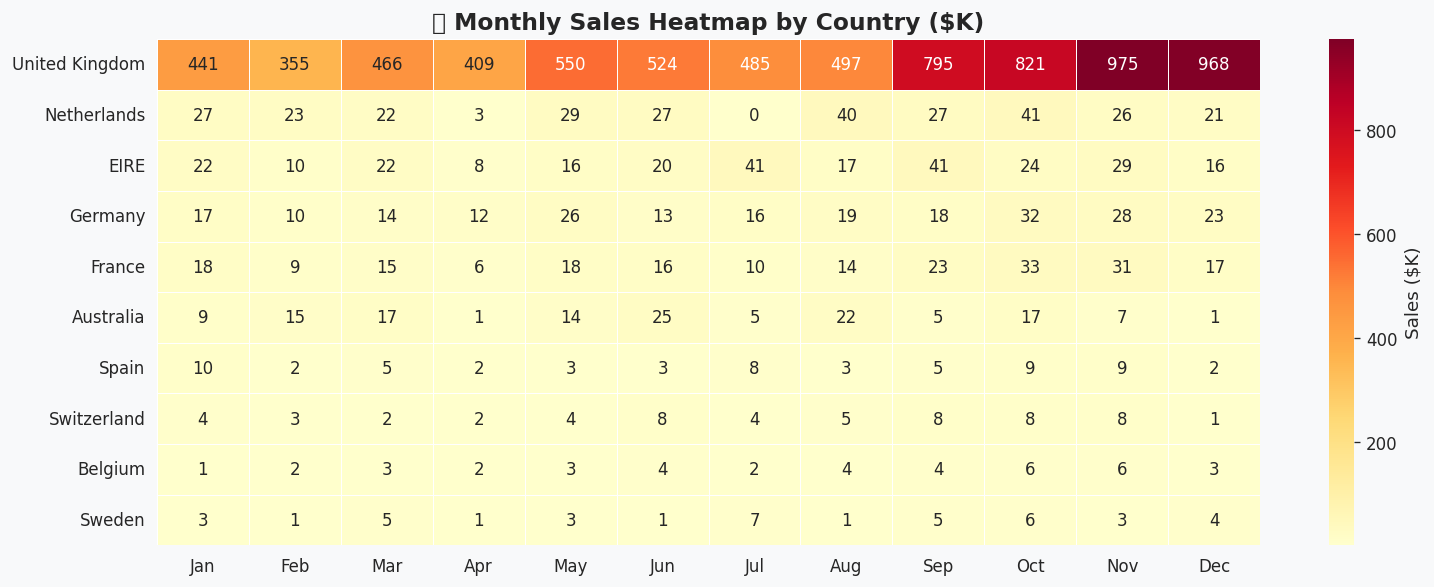

✅ Heatmap disimpan ke 'heatmap_sales.png'


In [ ]:
# =========================
# MONTHLY SALES HEATMAP
# =========================

fig_h, ax_h = plt.subplots(figsize=(13, 5))

# Background color
fig_h.patch.set_facecolor("#F8F9FA")
ax_h.set_facecolor("#F8F9FA")

# =========================
# PIVOT TABLE
# =========================

# Heatmap berdasarkan Country
hm = df.pivot_table(
    values="TotalPrice",
    index="Country",
    columns="Month_Name",
    aggfunc="sum"
)

# Urutan bulan
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Susun ulang kolom bulan
hm = hm.reindex(
    columns=[m for m in month_order if m in hm.columns]
)

# Ambil Top 10 Country berdasarkan total sales
top_country = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

hm = hm.loc[top_country]

# =========================
# HEATMAP
# =========================

sns.heatmap(
    hm / 1e3,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax_h,
    cbar_kws={"label": "Sales ($K)"}
)

# =========================
# CUSTOMIZATION
# =========================

ax_h.set_title(
    "🗓️ Monthly Sales Heatmap by Country ($K)",
    fontsize=14,
    fontweight="bold"
)

ax_h.set_xlabel("")
ax_h.set_ylabel("")

plt.tight_layout()

# Save image
plt.savefig(
    "heatmap_sales.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

print("✅ Heatmap disimpan ke 'heatmap_sales.png'")

## Cell 7 — Step 5: Business Insights
> ✏️ **Isi insight-mu di sini!** Ubah teks placeholder dengan temuan dari analisismu.

In [ ]:
# =========================
# BUSINESS INSIGHTS & RECOMMENDATIONS
# =========================

# Top country
top_country = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .idxmax()
)

top_country_sales = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .max()
)

# Peak sales hour
peak_hour = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
    .idxmax()
)

peak_hour_sales = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
    .max()
)

# Top product
top_product = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .idxmax()
)

top_product_sales = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .max()
)

# Monthly sales growth
monthly_growth = (
    df.groupby("Month_Name")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

best_month = monthly_growth.index[0]


In [ ]:
# =========================
# PRINT INSIGHTS
# =========================

print("=" * 60)
print("📊 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print(f"""
💡 INSIGHT 1 — TOP MARKET
   Negara dengan penjualan tertinggi adalah {top_country}
   dengan total revenue sebesar ${top_country_sales:,.2f}

   → Fokuskan strategi marketing dan customer retention
     pada market dengan performa tertinggi.

💡 INSIGHT 2 — PEAK TRANSACTION HOUR
   Jam transaksi paling ramai terjadi pada pukul {peak_hour}:00
   dengan total sales mencapai ${peak_hour_sales:,.2f}

   → Optimalkan promosi dan stok produk pada jam sibuk.

💡 INSIGHT 3 — BEST SELLING PRODUCT
   Produk terlaris adalah:
   "{top_product}"

   dengan total revenue sebesar ${top_product_sales:,.2f}

   → Tingkatkan persediaan dan promosi produk best seller.

💡 INSIGHT 4 — SEASONAL TREND
   Bulan dengan performa penjualan tertinggi adalah {best_month}

   → Persiapkan campaign dan inventory lebih awal
     menjelang high season.

💡 RECOMMENDATIONS:
   1. Fokus mempertahankan customer dari negara dengan revenue tertinggi.
   2. Tingkatkan stok untuk produk best seller.
   3. Jalankan flash sale pada jam transaksi paling ramai.
   4. Persiapkan strategi marketing menjelang high season.
   5. Gunakan customer segmentation untuk personalized promotion.
""")

📊 BUSINESS INSIGHTS & RECOMMENDATIONS

💡 INSIGHT 1 — TOP MARKET
   Negara dengan penjualan tertinggi adalah United Kingdom
   dengan total revenue sebesar $7,285,024.64

   → Fokuskan strategi marketing dan customer retention
     pada market dengan performa tertinggi.

💡 INSIGHT 2 — PEAK TRANSACTION HOUR
   Jam transaksi paling ramai terjadi pada pukul 12:00
   dengan total sales mencapai $1,373,695.39

   → Optimalkan promosi dan stok produk pada jam sibuk.

💡 INSIGHT 3 — BEST SELLING PRODUCT
   Produk terlaris adalah:
   "PAPER CRAFT , LITTLE BIRDIE"

   dengan total revenue sebesar $168,469.60

   → Tingkatkan persediaan dan promosi produk best seller.

💡 INSIGHT 4 — SEASONAL TREND
   Bulan dengan performa penjualan tertinggi adalah Nov

   → Persiapkan campaign dan inventory lebih awal
     menjelang high season.

💡 RECOMMENDATIONS:
   1. Fokus mempertahankan customer dari negara dengan revenue tertinggi.
   2. Tingkatkan stok untuk produk best seller.
   3. Jalankan flash sale pa

## Cell 8 — ✏️ YOUR TURN — Challenge Tasks

Selesaikan tasks berikut untuk memperkuat portfolio kamu:

In [ ]:
# =========================================================
# LEVEL 1 TASKS — ONLINE RETAIL DATASET
# =========================================================

# =========================================================
# TASK 1 — CUSTOMER LIFETIME VALUE (CLV) SEDERHANA
# =========================================================

clv = df.groupby("CustomerID").agg(
    Total_Spend=("TotalPrice", "sum"),
    Num_Orders=("InvoiceNo", "nunique"),
    Total_Items=("Quantity", "sum")
)

# Average Order Value
clv["Avg_Order_Value"] = (
    clv["Total_Spend"] / clv["Num_Orders"]
).round(2)

# Customer ranking
clv = clv.sort_values(
    "Total_Spend",
    ascending=False
)

print("=" * 60)
print("🏆 TOP 10 CUSTOMER CLV")
print("=" * 60)

print(clv.head(10))

# =========================================================
# TASK 2 — TOP 5 PRODUK DENGAN SALES TERENDAH
# =========================================================

lowest_products = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values()
    .head(5)
)

print("\n" + "=" * 60)
print("📉 TOP 5 LOWEST SALES PRODUCTS")
print("=" * 60)

print(lowest_products)

# =========================================================
# TASK 3 — PROFITABILITY ANALYSIS PER COUNTRY
# =========================================================

country_perf = df.groupby("Country").agg(
    Total_Sales=("TotalPrice", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Customers=("CustomerID", "nunique"),
    Total_Quantity=("Quantity", "sum")
)

# Average order value
country_perf["Avg_Order_Value"] = (
    country_perf["Total_Sales"] / country_perf["Total_Orders"]
).round(2)

# Sort by sales
country_perf = country_perf.sort_values(
    "Total_Sales",
    ascending=False
)

print("\n" + "=" * 60)
print("🌍 COUNTRY PERFORMANCE ANALYSIS")
print("=" * 60)

print(country_perf.head(10))

# =========================================================
# TASK 4 — TOP 10 BEST SELLING PRODUCTS
# =========================================================

top_products = df.groupby("Description").agg(
    Total_Sales=("TotalPrice", "sum"),
    Quantity_Sold=("Quantity", "sum")
)

top_products = top_products.sort_values(
    "Total_Sales",
    ascending=False
)

print("\n" + "=" * 60)
print("🛒 TOP 10 BEST SELLING PRODUCTS")
print("=" * 60)

print(top_products.head(10))

# =========================================================
# TASK 5 — MONTHLY SALES PERFORMANCE
# =========================================================

monthly_sales = df.groupby(
    ["Year", "Month_Name"]
)["TotalPrice"].sum().reset_index()

monthly_sales = monthly_sales.sort_values(
    "TotalPrice",
    ascending=False
)

print("\n" + "=" * 60)
print("📅 MONTHLY SALES PERFORMANCE")
print("=" * 60)

print(monthly_sales.head(10))

🏆 TOP 10 CUSTOMER CLV
            Total_Spend  Num_Orders  Total_Items  Avg_Order_Value
CustomerID                                                       
14646         280206.02          73       196915          3838.44
18102         259657.30          60        64124          4327.62
17450         194390.79          46        69973          4225.89
16446         168472.50           2        80997         84236.25
14911         143711.17         201        80240           714.98
12415         124914.53          21        77374          5948.31
14156         117210.08          55        57768          2131.09
17511          91062.38          31        64549          2937.50
16029          80850.84          63        40108          1283.35
12346          77183.60           1        74215         77183.60

📉 TOP 5 LOWEST SALES PRODUCTS
Description
PADS TO MATCH ALL CUSHIONS         0.003
HEN HOUSE W CHICK IN NEST          0.420
SET 12 COLOURING PENCILS DOILEY    0.650
VINTAGE BLUE TINSEL 

---
## 🏁 Next Steps
1. Selesaikan **Challenge Tasks** di Cell 8
2. Simpan sebagai `ecommerce_analysis.ipynb`
3. Upload ke **GitHub** (buat repo: `ecommerce-sales-analysis`)
4. Screenshot **2–3 chart terbaik**
5. Buat **LinkedIn Post** dalam 7 hari!

```
Template Caption LinkedIn:
"[Hook sentence] 💡
📊 Analisis: Superstore Sales Dataset
🛠️ Tools: Python | Pandas | Seaborn
🔍 Key Findings:
• [Insight 1]
• [Insight 2]
• [Insight 3]
👉 Full notebook: [GitHub link]
#DataAnalytics #Python #Portfolio"
```

**Good luck! Kamu pasti bisa 🚀**